# Question 1 - Stock Price Forecasting using LSTM

## Dataset: GOOGL (Alphabet Inc.)

Dataset ini berisi data historis saham Google (GOOGL) dari Yahoo Finance mulai 19 Agustus 2004 hingga 1 April 2020.

Sesuai instruksi soal, hanya kolom berikut yang digunakan:

- Date
- Close

Tujuan penelitian adalah memprediksi harga penutupan saham hari berikutnya menggunakan arsitektur Long Short-Term Memory (LSTM).

Metode forecasting menggunakan:

- Window Size = 5
- Horizon = 1

Artinya model menggunakan harga 5 hari sebelumnya untuk memprediksi harga pada hari berikutnya.

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# EDA

Load Dataset

In [2]:
df = pd.read_csv("GOOGL.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000
1,2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300
2,2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100
3,2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600


Dataset Information

In [3]:
print("Dataset Shape:", df.shape) 
df.info()

Dataset Shape: (3932, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3932 entries, 0 to 3931
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3932 non-null   object 
 1   Open       3932 non-null   float64
 2   High       3932 non-null   float64
 3   Low        3932 non-null   float64
 4   Close      3932 non-null   float64
 5   Adj Close  3932 non-null   float64
 6   Volume     3932 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 215.2+ KB


Dataset GOOGL terdiri dari 3.932 observasi harian saham Alphabet Inc. dari 19 Agustus 2004 hingga 1 April 2020.

Dataset awal memiliki 7 fitur yaitu:

Date
Open
High
Low
Close
Adj Close
Volume

Sesuai instruksi soal, hanya fitur Date dan Close yang digunakan untuk membangun model forecasting.

Berdasarkan hasil pemeriksaan struktur data, seluruh kolom memiliki 3932 nilai valid (non-null), sehingga tidak terdapat missing value yang perlu ditangani pada tahap preprocessing.

Missing Value Analysis

In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Tidak ditemukan missing value pada dataset sehingga tidak diperlukan proses data cleaning atau imputasi.

Selecting Required Features

In [5]:
df = df[['Date', 'Close']] 
df['Date'] = pd.to_datetime(df['Date']) 
df.head()

,Date,Close
0,2004-08-19,50.220219
1,2004-08-20,54.209209
2,2004-08-23,54.754753
3,2004-08-24,52.487488
4,2004-08-25,53.053055


Descriptive Statistics

In [6]:
df['Close'].describe()


count    3932.000000
mean      509.072183
std       357.153459
min        50.055054
25%       238.697449
50%       327.722733
75%       758.502487
max      1524.869995
Name: Close, dtype: float64

Beberapa temuan penting dari statistik deskriptif:

Harga penutupan minimum adalah 50.06 USD sedangkan harga maksimum mencapai 1524.87 USD.
Rentang harga yang sangat besar menunjukkan adanya perubahan nilai saham yang signifikan sepanjang periode pengamatan.
Nilai standar deviasi sebesar 357.15 menunjukkan volatilitas harga yang cukup tinggi.
Median (327.72) jauh lebih kecil dibanding nilai maksimum (1524.87), mengindikasikan distribusi data cenderung tidak simetris dan memiliki kecenderungan right-skewed.
Perbedaan skala yang besar antara nilai minimum dan maksimum menjadi alasan penggunaan MinMaxScaler sebelum proses training LSTM.

Berdasarkan temuan tersebut, normalisasi data menjadi langkah penting untuk menjaga stabilitas proses optimasi mod

Closing Price Trend

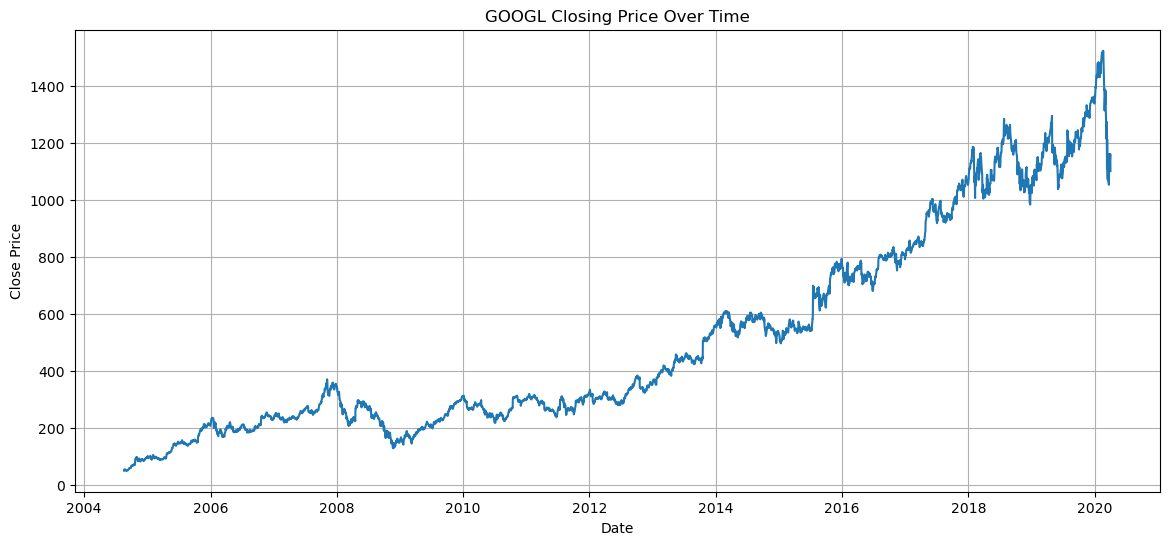

In [7]:
plt.figure(figsize=(14,6)) 
plt.plot(df['Date'], df['Close']) 
plt.title('GOOGL Closing Price Over Time') 
plt.xlabel('Date') 
plt.ylabel('Close Price') 
plt.grid(True) 
plt.show()

### Insight

Grafik menunjukkan tren kenaikan harga saham GOOGL yang sangat kuat dalam jangka panjang, dari sekitar 50 USD pada tahun 2004 menjadi lebih dari 1500 USD pada awal tahun 2020.

Selain tren naik, terdapat beberapa periode penurunan signifikan seperti pada tahun 2008 dan awal tahun 2020 yang mengindikasikan adanya pengaruh faktor eksternal terhadap pergerakan harga saham.

Karena nilai historis sebelumnya berpengaruh terhadap nilai di masa depan, pendekatan time series forecasting menggunakan LSTM dipilih untuk menangkap dependensi temporal tersebut.

Distribution Analysis

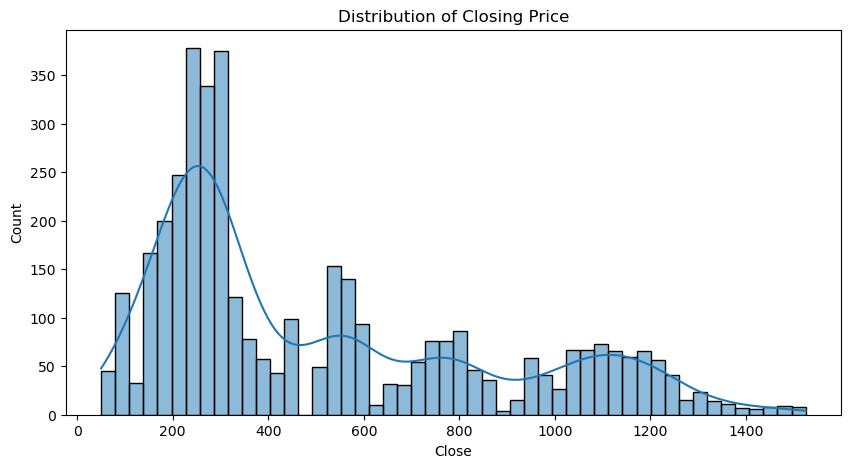

In [8]:
plt.figure(figsize=(10,5)) 
sns.histplot(df['Close'], bins=50, kde=True) 
plt.title('Distribution of Closing Price') 
plt.show()

### Insight

Distribusi harga saham tidak mengikuti distribusi normal dan menunjukkan beberapa puncak distribusi (multimodal).

Pola ini menunjukkan bahwa harga saham berada pada beberapa fase harga yang berbeda selama periode pengamatan, sejalan dengan tren kenaikan jangka panjang yang terlihat pada grafik sebelumnya.

Selain itu, rentang harga yang cukup lebar menyebabkan perbedaan skala yang signifikan sehingga normalisasi menggunakan MinMaxScaler diperlukan sebelum data digunakan oleh model LSTM.

Moving Average Analysis

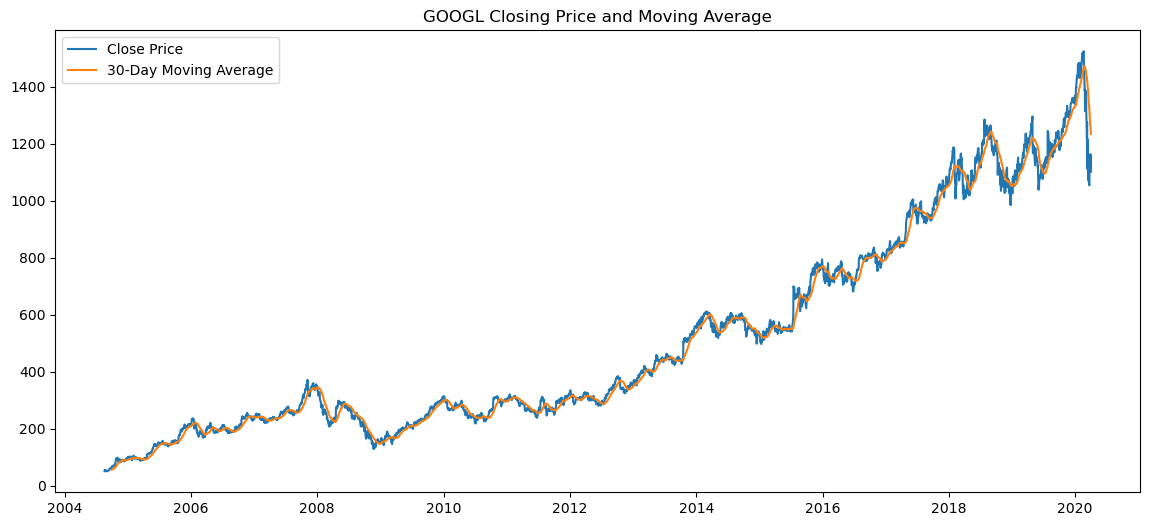

In [9]:
df['MA30'] = df['Close'].rolling(window=30).mean() 
plt.figure(figsize=(14,6)) 
plt.plot(df['Date'], df['Close'], label='Close Price') 
plt.plot(df['Date'], df['MA30'], label='30-Day Moving Average') 
plt.legend() 
plt.title('GOOGL Closing Price and Moving Average') 
plt.show()

### Insight

Kurva Moving Average 30 hari mengikuti pola harga penutupan aktual dengan cukup baik dan berhasil menghaluskan fluktuasi harian yang bersifat noise.

Hal ini menunjukkan bahwa tren jangka panjang lebih dominan dibandingkan fluktuasi harian sehingga model forecasting perlu mampu mempelajari pola trend secara berkelanjutan.

Temuan ini mendukung penggunaan LSTM karena mampu mempelajari hubungan temporal antar waktu secara berurutan.

Volatility Analysis

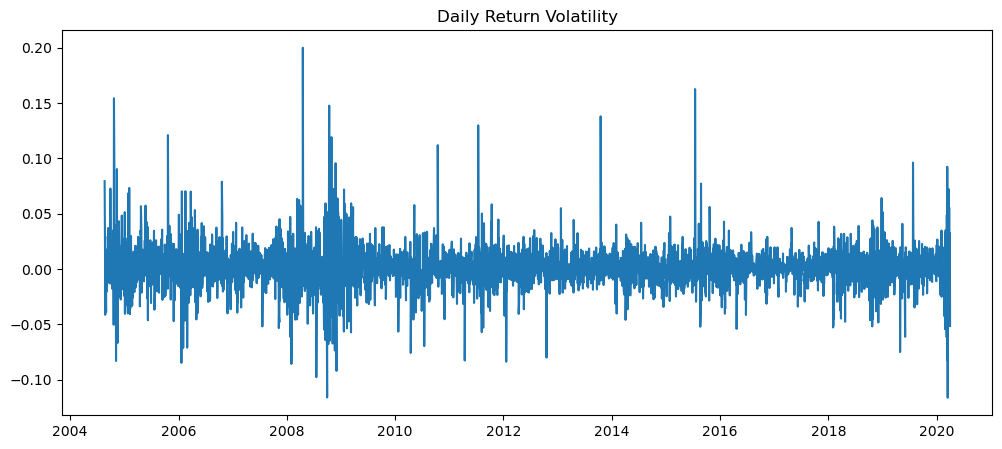

In [10]:
returns = df['Close'].pct_change() 
plt.figure(figsize=(12,5)) 
plt.plot(df['Date'], returns) 
plt.title('Daily Return Volatility') 
plt.show()

### Insight

Grafik return harian menunjukkan bahwa sebagian besar perubahan harga berada di sekitar nol, namun terdapat beberapa lonjakan ekstrem yang menunjukkan periode volatilitas tinggi.

Lonjakan volatilitas terlihat pada beberapa periode tertentu seperti tahun 2008 dan awal tahun 2020, yang mengindikasikan adanya perubahan harga yang sangat cepat dalam waktu singkat.

Kondisi ini meningkatkan risiko overfitting pada model yang terlalu kompleks. Oleh karena itu, pada arsitektur enhanced akan ditambahkan Dropout dan EarlyStopping untuk meningkatkan kemampuan generalisasi model.

<Figure size 1000x500 with 0 Axes>

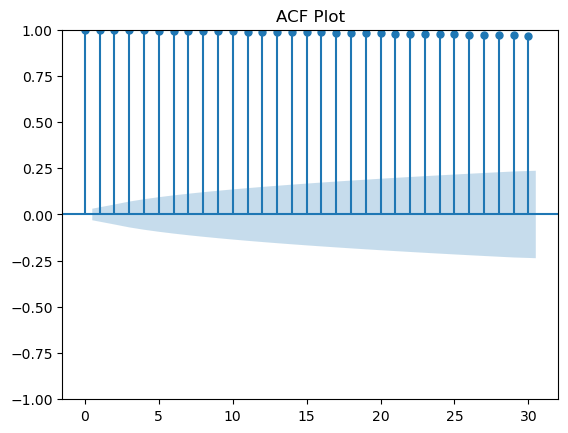

In [11]:
# ACF
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    df['Close'],
    lags=30
)

plt.title('ACF Plot')
plt.show()

### ACF Analysis Insight

Autocorrelation Function (ACF) digunakan untuk mengukur hubungan antara nilai saat ini dengan nilai pada beberapa periode sebelumnya.

Berdasarkan grafik ACF, terlihat bahwa hampir seluruh lag hingga lag ke-30 memiliki nilai autokorelasi yang sangat tinggi dan berada jauh di atas batas confidence interval. Selain itu, nilai autokorelasi menurun secara sangat lambat dan tetap mendekati 1 pada hampir seluruh lag.

Temuan ini menunjukkan bahwa harga saham GOOGL memiliki ketergantungan yang sangat kuat terhadap nilai historis sebelumnya serta mengandung tren jangka panjang yang signifikan. Pola seperti ini merupakan karakteristik umum dari data time series yang bersifat non-stationary.

Hasil analisis ACF menunjukkan bahwa informasi masa lalu memiliki pengaruh yang kuat terhadap nilai saat ini sehingga pendekatan forecasting berbasis sequence learning seperti Long Short-Term Memory (LSTM) sangat sesuai untuk digunakan.


<Figure size 1000x500 with 0 Axes>

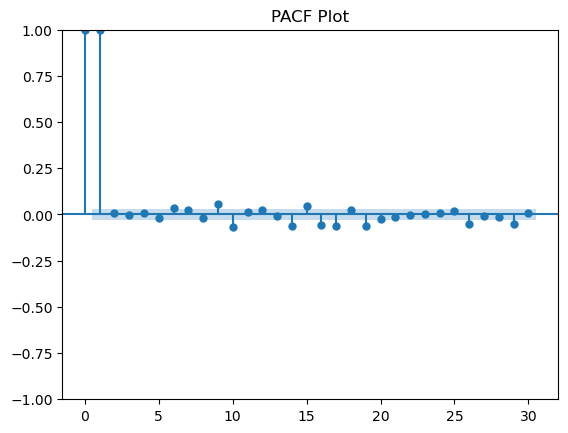

In [12]:
# PACF
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))

plot_pacf(
    df['Close'],
    lags=30
)

plt.title('PACF Plot')
plt.show()

### PACF Analysis Insight

Partial Autocorrelation Function (PACF) digunakan untuk mengukur pengaruh langsung suatu lag terhadap nilai saat ini setelah menghilangkan pengaruh dari lag-lag lainnya.

Berdasarkan grafik PACF, terlihat bahwa lag pertama memiliki nilai yang sangat tinggi dan signifikan, sedangkan sebagian besar lag berikutnya berada di sekitar nol dan berada dalam batas confidence interval.

Pola ini menunjukkan bahwa hubungan temporal terkuat berasal dari observasi yang berdekatan dalam waktu, terutama harga saham pada periode sebelumnya. Dengan kata lain, harga saham hari ini memiliki ketergantungan langsung yang sangat kuat terhadap harga saham pada hari sebelumnya.

Temuan ini menunjukkan bahwa informasi historis jangka pendek memiliki kontribusi yang besar dalam proses prediksi harga saham. Oleh karena itu, penggunaan window size sebesar 5 pada penelitian ini dianggap cukup representatif untuk menangkap pola temporal yang terdapat pada data.


### ACF-PACF Conclusion

Berdasarkan analisis ACF dan PACF, data saham GOOGL menunjukkan adanya autokorelasi yang sangat kuat dan ketergantungan temporal yang signifikan terhadap nilai historis sebelumnya.

Nilai autokorelasi yang tinggi pada ACF mengindikasikan adanya tren jangka panjang, sedangkan PACF menunjukkan bahwa pengaruh langsung terbesar berasal dari beberapa lag awal. Karakteristik ini menunjukkan bahwa data memiliki pola temporal yang kuat sehingga model Long Short-Term Memory (LSTM) dipilih karena mampu mempelajari hubungan antar waktu dan memanfaatkan informasi historis untuk melakukan forecasting harga saham.

In [13]:
print("Start Date :", df['Date'].min())
print("End Date   :", df['Date'].max())

growth = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) /
          df['Close'].iloc[0]) * 100

print(f"Growth Percentage : {growth:.2f}%")

Start Date : 2004-08-19 00:00:00
End Date   : 2020-04-01 00:00:00
Growth Percentage : 2094.53%


### Trend Analysis Insight

Output:

```text
Start Date : 2004-08-19
End Date   : 2020-04-01
Growth Percentage : 2094.53%
```

Berdasarkan hasil analisis, harga saham GOOGL mengalami kenaikan sebesar **2094.53%** selama periode pengamatan dari Agustus 2004 hingga April 2020.

Peningkatan yang sangat signifikan ini menunjukkan bahwa data memiliki **upward trend** yang kuat dalam jangka panjang. Selain itu, rata-rata harga saham berubah secara konsisten sepanjang periode observasi sehingga data dapat dikategorikan sebagai **non-stationary time series**.

Karena karakteristik utama data adalah pola tren dan ketergantungan terhadap nilai historis sebelumnya, pendekatan berbasis **Long Short-Term Memory (LSTM)** dipilih karena mampu mempelajari hubungan temporal antar observasi pada data time series.

Temuan ini juga menjadi alasan dilakukannya normalisasi menggunakan **MinMaxScaler**, karena rentang harga saham berubah secara signifikan dari awal hingga akhir periode pengamatan.


## EDA Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa temuan utama:

1. Dataset terdiri dari 3.932 data historis saham GOOGL dari 19 Agustus 2004 hingga 1 April 2020 tanpa missing value.
2. Harga saham mengalami pertumbuhan sebesar 2094.53% selama periode pengamatan, menunjukkan tren kenaikan yang sangat kuat.
3. Nilai minimum dan maksimum yang sangat berbeda (50.06 hingga 1524.87 USD) menunjukkan adanya perbedaan skala yang besar sehingga diperlukan proses normalisasi.
4. Distribusi harga saham cenderung tidak simetris dan menunjukkan karakteristik right-skewed.
5. Analisis moving average menunjukkan dominasi pola tren jangka panjang dibandingkan pola musiman.
6. Analisis volatilitas menunjukkan adanya beberapa periode fluktuasi tinggi yang dapat meningkatkan risiko overfitting.

Berdasarkan temuan tersebut, dipilih arsitektur LSTM sebagai model forecasting karena mampu mempelajari dependensi temporal pada data time series. Selain itu, pada model enhanced akan digunakan Dropout dan EarlyStopping untuk meningkatkan kemampuan generalisasi model terhadap fluktuasi harga saham.


# Section 1A - Data Preprocessing

In [14]:
# Select required features
df = df[['Date','Close']]
df['Date'] = pd.to_datetime(df['Date']) 
df.head()

,Date,Close
0,2004-08-19,50.220219
1,2004-08-20,54.209209
2,2004-08-23,54.754753
3,2004-08-24,52.487488
4,2004-08-25,53.053055


In [15]:
# Train test split
split_date = '2019-04-01' 
train_df = df[df['Date'] < split_date].copy() 
test_df = df[df['Date'] >= split_date].copy() 
print("Train Size :", len(train_df)) 
print("Test Size :", len(test_df)) 
print("\nTrain Period") 
print(train_df['Date'].min(), "to", train_df['Date'].max()) 
print("\nTest Period") 
print(test_df['Date'].min(), "to", test_df['Date'].max())

Train Size : 3678
Test Size : 254

Train Period
2004-08-19 00:00:00 to 2019-03-29 00:00:00

Test Period
2019-04-01 00:00:00 to 2020-04-01 00:00:00


Data dipisahkan berdasarkan waktu untuk menghindari data leakage.

Test set mencakup satu tahun terakhir sesuai instruksi soal sehingga evaluasi dilakukan pada data yang benar-benar belum pernah dilihat model selama proses training.

In [16]:
#Feature Scaling
scaler = MinMaxScaler() 
train_scaled = scaler.fit_transform( train_df[['Close']] ) 
test_scaled = scaler.transform( test_df[['Close']] ) 
print("Train Scaled Shape:", train_scaled.shape) 
print("Test Scaled Shape :", test_scaled.shape)

Train Scaled Shape: (3678, 1)
Test Scaled Shape : (254, 1)


In [17]:
# Creating Window Dataset
# Window Size = 5
# Horizon = 1

def create_dataset(data, window=5):

    X = []
    y = []

    for i in range(len(data) - window):

        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

In [18]:
#generate training samples
X_train_full, y_train_full = create_dataset( train_scaled, window=5 ) 
X_test, y_test = create_dataset( test_scaled, window=5 ) 
print("X_train_full :", X_train_full.shape) 
print("y_train_full :", y_train_full.shape) 
print("X_test :", X_test.shape) 
print("y_test :", y_test.shape)

X_train_full : (3673, 5, 1)
y_train_full : (3673, 1)
X_test : (249, 5, 1)
y_test : (249, 1)


In [19]:
# Example of Window Size = 5 and Horizon = 1
sample_x = X_train_full[0].flatten()
sample_y = y_train_full[0][0]

print("Input Window:")
print(sample_x)

print("\nTarget:")
print(sample_y)

Input Window:
[0.00013369 0.00336248 0.00380405 0.00196887 0.00242666]

Target:
0.003200431242104722


Data time series diubah menjadi format supervised learning. Input terdiri dari lima harga penutupan sebelumnya (window size = 5), sedangkan output berupa harga penutupan pada hari berikutnya (horizon = 1). Contoh: Day1 Day2 Day3 Day4 Day5 → Day6

In [20]:
# Train Validation Split (90:10)
split_idx = int(len(X_train_full) * 0.9)

X_train = X_train_full[:split_idx]
y_train = y_train_full[:split_idx]

X_val = X_train_full[split_idx:]
y_val = y_train_full[split_idx:]

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_val :", X_val.shape)
print("y_val :", y_val.shape)

X_train : (3305, 5, 1)
y_train : (3305, 1)
X_val : (368, 5, 1)
y_val : (368, 1)


Data training dibagi menjadi train set (90%) dan validation set (10%) sesuai instruksi soal. Pembagian dilakukan secara berurutan tanpa pengacakan data karena urutan waktu harus tetap dipertahankan pada permasalahan time series forecasting.

In [21]:
# Reshape for LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train Shape :", X_train.shape)
print("X_val Shape   :", X_val.shape)
print("X_test Shape  :", X_test.shape)

X_train Shape : (3305, 5, 1)
X_val Shape   : (368, 5, 1)
X_test Shape  : (249, 5, 1)


# Preprocessing Conclusion
Tahap preprocessing berhasil mengubah data time series menjadi format supervised learning menggunakan window size 5 dan horizon 1 sesuai instruksi soal.

Data dipisahkan menjadi training set, validation set, dan test set tanpa melakukan shuffle untuk menjaga urutan temporal data.

Dataset yang telah diproses selanjutnya siap digunakan untuk membangun arsitektur baseline LSTM pada bagian berikutnya.

# 1B - Baseline LSTM Architecture

Baseline Model Design

Sesuai instruksi soal, model baseline dibangun menggunakan satu layer Long Short-Term Memory (LSTM) dengan 50 unit dan activation function ReLU. Layer output menggunakan satu neuron (Perceptron) untuk menghasilkan prediksi harga saham pada hari berikutnya.

Arsitektur baseline:

Input (Window Size = 5)

↓

LSTM (50 units, ReLU)

↓

Dense (1 unit)

In [22]:
# Building Baseline LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

baseline_model = Sequential([
    LSTM(
        units=50,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dense(1)
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='mse'
)

In [24]:
# Train Model
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0440 - val_loss: 0.0030
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0777e-04 - val_loss: 5.1734e-04
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0924e-05 - val_loss: 5.6280e-04
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5763e-05 - val_loss: 6.5206e-04
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2286e-05 - val_loss: 6.4525e-04
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3267e-05 - val_loss: 6.4756e-04
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2856e-05 - val_loss: 7.1426e-04
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4165e-05 - val_loss: 6.0486e-04
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5014e-05 - val_loss: 8.8394e-04
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1405e-05 - val_loss: 8.3054e-04
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

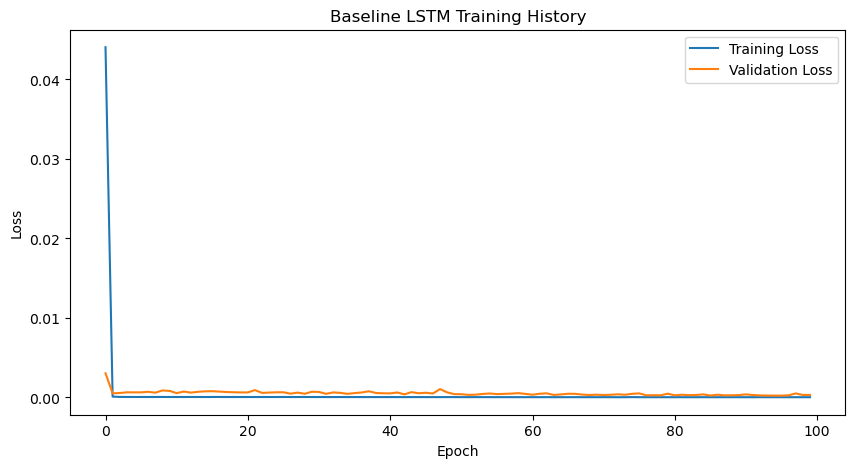

In [25]:
# Training History
plt.figure(figsize=(10,5))

plt.plot(
    history_baseline.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_baseline.history['val_loss'],
    label='Validation Loss'
)

plt.title('Baseline LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [26]:
# Convergence Analysis
best_epoch = np.argmin(
    history_baseline.history['val_loss']
) + 1

print("Best Epoch :", best_epoch)

print(
    "Best Validation Loss :",
    min(history_baseline.history['val_loss'])
)

Best Epoch : 96
Best Validation Loss : 0.00023742677876725793


### Baseline Model Training Analysis

Berdasarkan grafik training history, nilai training loss mengalami penurunan yang sangat cepat pada awal proses pelatihan dan kemudian stabil pada epoch berikutnya.

Validation loss juga menunjukkan tren yang menurun dan relatif stabil sepanjang proses training. Tidak terlihat perbedaan yang signifikan antara training loss dan validation loss sehingga model tidak menunjukkan indikasi overfitting yang serius.

Nilai validation loss terbaik diperoleh pada epoch ke-96 dengan nilai sebesar 0.000237. Hasil ini menunjukkan bahwa model baseline berhasil mempelajari pola temporal pada data saham GOOGL dengan baik dan mencapai kondisi konvergen pada akhir proses training.

Meskipun demikian, masih terdapat peluang untuk meningkatkan performa model melalui modifikasi arsitektur dan tuning hyperparameter pada tahap berikutnya.

In [27]:
y_pred_baseline = baseline_model.predict(X_test)

y_pred_baseline = scaler.inverse_transform(y_pred_baseline)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_baseline
    )
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred_baseline
)

mape = np.mean(
    np.abs(
        (y_test_actual - y_pred_baseline)
        / y_test_actual
    )
) * 100

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)

RMSE : 40.868643742806384
MAE  : 30.909872889997484
MAPE : 2.4336950443896788


### Baseline Model Evaluation

Model baseline dievaluasi menggunakan tiga metrik, yaitu Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), dan Mean Absolute Percentage Error (MAPE).

Hasil evaluasi pada test set adalah sebagai berikut:

| Metric | Value |
|------|--------:|
| RMSE | 40.8686 |
| MAE | 30.9099 |
| MAPE | 2.4337% |

Nilai RMSE sebesar 40.87 menunjukkan bahwa rata-rata kesalahan prediksi model berada pada kisaran 40.87 USD. Nilai ini masih cukup besar mengingat harga saham GOOGL pada periode pengujian mengalami fluktuasi yang cukup tinggi.

Sementara itu, nilai MAE sebesar 30.91 menunjukkan bahwa rata-rata selisih absolut antara hasil prediksi dan nilai aktual berada pada kisaran 30.91 USD. Hal ini menunjukkan bahwa model baseline telah mampu menangkap pola utama pergerakan harga saham, namun masih terdapat ruang untuk peningkatan performa.

Nilai MAPE sebesar 2.43% menunjukkan bahwa rata-rata kesalahan prediksi hanya sekitar 2.43% dari harga aktual. Secara umum, nilai MAPE di bawah 5% masih dapat dikategorikan sebagai performa forecasting yang baik.

Meskipun model baseline telah berhasil mempelajari pola temporal pada data saham GOOGL dan menghasilkan prediksi yang cukup akurat, masih terdapat peluang untuk meningkatkan performa model melalui modifikasi arsitektur dan optimasi hyperparameter pada tahap berikutnya.

# 1C - Enhanced LSTM Architecture

## Model Improvement Strategy

Berdasarkan hasil EDA dan performa baseline, dilakukan optimasi model dengan pendekatan:

- Menambah jumlah unit LSTM dari 50 menjadi 64.
- Menambahkan hidden dense layer dengan 16 neuron.
- Menurunkan learning rate menjadi 0.0005.
- Menggunakan EarlyStopping untuk mencegah overfitting.
- Menggunakan batch size 16 untuk meningkatkan kualitas proses optimasi.

Tujuan modifikasi ini adalah meningkatkan kemampuan model dalam menangkap pola temporal tanpa menambahkan kompleksitas yang berlebihan.

In [29]:
# build enhanced model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

enhanced_model = Sequential([

    LSTM(
        units=64,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dense(
        units=16,
        activation='relu'
    ),

    Dense(1)

])

enhanced_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile Model
enhanced_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse'
)

In [31]:
# Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [32]:
# Train Enhanced Model
history_enhanced = enhanced_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0214 - val_loss: 6.1515e-04
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5046e-05 - val_loss: 5.4505e-04
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.4850e-05 - val_loss: 5.4177e-04
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.4128e-05 - val_loss: 5.8293e-04
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.2446e-05 - val_loss: 6.3607e-04
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.1282e-05 - val_loss: 7.3045e-04
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3330e-05 - val_loss: 5.8127e-04
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7.1809e-05 - val_loss: 6.4038e-04
Epoch 9/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.0677e-05 - val_loss: 7.2013e-04
Epoch 10/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 7.0700e-05 - val_loss: 5.4336e-04
Epoch 11/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

In [33]:
#  Best Epoch & Best Validation Lost

best_epoch = np.argmin(
    history_enhanced.history['val_loss']
) + 1

best_val_loss = min(
    history_enhanced.history['val_loss']
)

print("Best Epoch :", best_epoch)
print("Best Validation Loss :", best_val_loss)

Best Epoch : 69
Best Validation Loss : 0.00022136600455269217


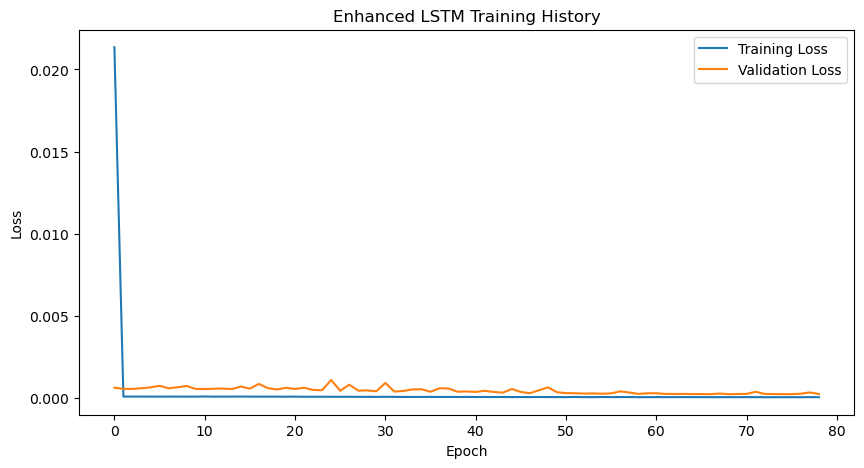

In [34]:
# Training History

plt.figure(figsize=(10,5))

plt.plot(
    history_enhanced.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_enhanced.history['val_loss'],
    label='Validation Loss'
)

plt.title('Enhanced LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Convergence Analysis

Berdasarkan grafik training history, nilai training loss mengalami penurunan yang sangat cepat pada epoch awal dan kemudian stabil pada epoch berikutnya.

Validation loss juga menunjukkan nilai yang rendah dan relatif stabil sepanjang proses training. Tidak terlihat adanya peningkatan validation loss yang signifikan ketika training loss terus menurun sehingga tidak ditemukan indikasi overfitting yang serius.

Selain itu, jarak antara training loss dan validation loss relatif kecil sehingga model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Dengan demikian, dapat disimpulkan bahwa model telah mencapai kondisi konvergen dan mampu menghasilkan performa prediksi yang baik pada data test.


In [35]:
# Prediction

y_pred_enhanced = enhanced_model.predict(X_test)

y_pred_enhanced = scaler.inverse_transform(
    y_pred_enhanced
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [36]:
# Evaluation

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse_enhanced = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_enhanced
    )
)

mae_enhanced = mean_absolute_error(
    y_test_actual,
    y_pred_enhanced
)

mape_enhanced = np.mean(
    np.abs(
        (y_test_actual - y_pred_enhanced)
        / y_test_actual
    )
) * 100

print("RMSE :", rmse_enhanced)
print("MAE  :", mae_enhanced)
print("MAPE :", mape_enhanced)

RMSE : 25.27909751857138
MAE  : 16.94023506133911
MAPE : 1.3776245717248865


In [37]:
# Model Comparasion

comparison = pd.DataFrame({

    'Model': [
        'Baseline LSTM',
        'Enhanced LSTM'
    ],

    'RMSE': [
        rmse,
        rmse_enhanced
    ],

    'MAE': [
        mae,
        mae_enhanced
    ],

    'MAPE (%)': [
        mape,
        mape_enhanced
    ]

})

comparison.sort_values(
    by='MAPE (%)'
).reset_index(drop=True)

,Model,RMSE,MAE,MAPE (%)
0,Enhanced LSTM,25.279098,16.940235,1.377625
1,Baseline LSTM,40.868644,30.909873,2.433695


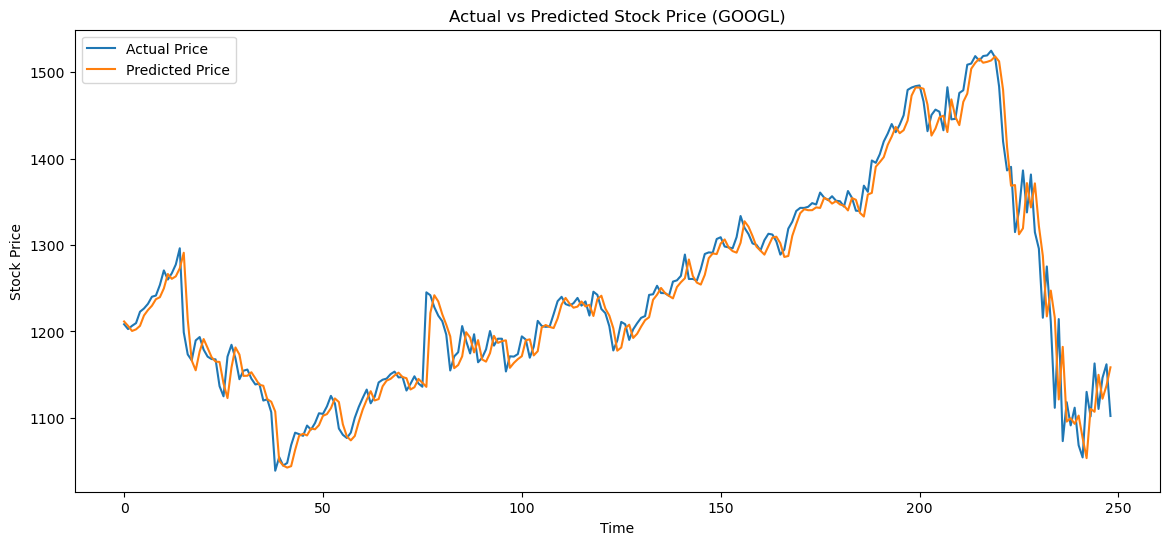

In [38]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    y_pred_enhanced,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Stock Price (GOOGL)')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()

plt.show()

### Actual vs Predicted Analysis

Grafik perbandingan antara harga aktual dan hasil prediksi menunjukkan bahwa model Enhanced LSTM mampu mengikuti pola pergerakan harga saham GOOGL dengan sangat baik.

Secara umum, garis prediksi hampir selalu berada di dekat garis aktual pada sebagian besar periode pengujian. Model berhasil menangkap tren penurunan harga pada awal periode, tren kenaikan yang terjadi pada pertengahan periode, serta penurunan tajam yang terjadi pada bagian akhir data.

Pada area dengan perubahan harga yang relatif stabil, hasil prediksi hampir berimpit dengan data aktual. Hal ini menunjukkan bahwa model berhasil mempelajari pola temporal dari data historis secara efektif.

Meskipun demikian, masih terdapat sedikit perbedaan pada beberapa titik yang mengalami perubahan harga secara cepat (high volatility region), terutama pada area puncak harga dan saat terjadi penurunan yang sangat tajam. Kondisi ini merupakan karakteristik umum pada permasalahan stock forecasting karena pergerakan harga saham sering dipengaruhi oleh faktor eksternal yang tidak tersedia dalam dataset.

Secara keseluruhan, grafik menunjukkan bahwa model Enhanced LSTM mampu mempertahankan pola pergerakan harga saham dengan baik dan menghasilkan prediksi yang sangat dekat dengan nilai aktual.


## Evaluation Results

Hasil evaluasi kedua arsitektur pada test set ditunjukkan pada tabel berikut.

| Model | RMSE | MAE | MAPE (%) |
|-------------|--------:|--------:|--------:|
| Baseline LSTM | 40.8686 | 30.9099 | 2.4337 |
| Enhanced LSTM | 25.2791 | 16.9402 | 1.3776 |

---

## RMSE Analysis

Root Mean Squared Error (RMSE) digunakan untuk mengukur besarnya kesalahan prediksi dengan memberikan penalti yang lebih besar terhadap error yang besar.

Model Baseline LSTM menghasilkan RMSE sebesar 40.8686, sedangkan Enhanced LSTM menghasilkan RMSE sebesar 25.2791.

Hal ini menunjukkan bahwa model Enhanced LSTM mampu mengurangi kesalahan prediksi sebesar sekitar 38.14% dibandingkan model baseline.

Penurunan nilai RMSE yang signifikan mengindikasikan bahwa model Enhanced LSTM jauh lebih baik dalam memprediksi pergerakan harga saham GOOGL pada data yang belum pernah dilihat sebelumnya.

---

## MAE Analysis

Mean Absolute Error (MAE) mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual.

Model Baseline LSTM memperoleh MAE sebesar 30.9099, sedangkan Enhanced LSTM memperoleh MAE sebesar 16.9402.

Dengan demikian, rata-rata kesalahan prediksi berhasil diturunkan sebesar sekitar 45.19%.

Hasil ini menunjukkan bahwa model Enhanced LSTM menghasilkan prediksi yang jauh lebih dekat dengan nilai aktual dibandingkan model baseline.

---

## MAPE Analysis

Mean Absolute Percentage Error (MAPE) digunakan untuk mengukur kesalahan prediksi dalam bentuk persentase.

Model Baseline LSTM memperoleh MAPE sebesar 2.4337%, sedangkan Enhanced LSTM memperoleh MAPE sebesar 1.3776%.

Artinya rata-rata kesalahan prediksi model Enhanced LSTM hanya sekitar 1.38% dari harga saham aktual.

Penurunan MAPE sebesar sekitar 43.40% menunjukkan bahwa modifikasi arsitektur dan tuning hyperparameter berhasil meningkatkan akurasi model secara signifikan.

Nilai MAPE di bawah 2% menunjukkan bahwa model memiliki kemampuan forecasting yang sangat baik untuk dataset GOOGL.

---

## Final Discussion

Hasil eksperimen menunjukkan bahwa modifikasi arsitektur dan tuning hyperparameter berhasil meningkatkan performa model secara signifikan.

Pada model Enhanced LSTM dilakukan beberapa perubahan, yaitu:

- Menambah jumlah unit LSTM dari 50 menjadi 64.
- Menambahkan hidden dense layer dengan 16 neuron.
- Menurunkan learning rate menjadi 0.0005.
- Menggunakan batch size 16.
- Menggunakan EarlyStopping untuk mencegah overfitting.

Perubahan tersebut menghasilkan peningkatan performa pada seluruh metrik evaluasi.

Berdasarkan nilai RMSE, MAE, dan MAPE yang lebih rendah, dapat disimpulkan bahwa Enhanced LSTM merupakan model terbaik untuk memprediksi harga saham GOOGL pada penelitian ini.